In [18]:
# 1 IMPORT LIBRARIES

# Bibliothèques de base
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement et modélisation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Métriques d'évaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


In [19]:
# 2 LOAD DATASET

# Source: UCI Machine Learning Repository
# Dataset: Auto MPG
# URL: https://archive.ics.uci.edu/ml/datasets/Auto+MPG
# Fichier: auto-mpg.data ou auto-mpg.data

# Définition des noms de colonnes selon la documentation UCI
column_names = [
    'mpg',           # Consommation (miles per gallon) CIBLE
    'cylinders',     # Nombre de cylindres
    'displacement',  # Cylindrée (cubic inches)
    'horsepower',    # Puissance (horsepower)
    'weight',        # Poids (lbs)
    'acceleration',  # Accélération (seconds to reach 60 mph)
    'model_year',    # Année du modèle
    'origin',        # Origine: 1=USA, 2=Europe, 3=Japan
    'car_name'       # Nom de la voiture (identifiant)
]

# Chargement du dataset
# Téléchargement via: https://archive.ics.uci.edu/static/public/9/auto+mpg.zip
try:
    df = pd.read_csv('auto-mpg.data', 
                     delim_whitespace=True, 
                     names=column_names,
                     na_values='?')
    print("✅ Dataset chargé avec succès depuis 'auto-mpg.data'")
except FileNotFoundError:
    # Tentative avec un autre nom de fichier possible
    try:
        df = pd.read_csv('auto-mpg.data.txt', 
                         delim_whitespace=True, 
                         names=column_names,
                         na_values='?')
        print("✅ Dataset chargé avec succès depuis 'auto-mpg.data.txt'")
    except FileNotFoundError:
        print("❌ Fichier non trouvé. Téléchargez depuis UCI:")
        print("   https://archive.ics.uci.edu/static/public/9/auto+mpg.zip")
        raise

print(f"\n📊 Dimensions du dataset: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print("\n📋 Aperçu des 5 premières lignes:")
df.head()

✅ Dataset chargé avec succès depuis 'auto-mpg.data'

📊 Dimensions du dataset: 398 lignes, 9 colonnes

📋 Aperçu des 5 premières lignes:


C:\Users\OMAR\AppData\Local\Temp\ipykernel_19516\3845961639.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('auto-mpg.data',


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


PROBLÉMATIQUE DU PROJET


📌 Question principale:
"Peut-on prédire la consommation d'une voiture à partir de ses caractéristiques techniques ?"

🎯 Objectif:
Construire un modèle de régression capable d'estimer la consommation de carburant
(mesurée en miles per gallon - mpg) en fonction des caractéristiques techniques
du véhicule (cylindrée, puissance, poids, accélération, année, origine).

📊 Type de problème:

Régression supervisée

Variable cible continue: mpg (consommation)

Variables explicatives: caractéristiques techniques du véhicule

💡 Intérêt métier:

Aide à la conception de véhicules plus économes

Estimation de la consommation pour les acheteurs

Analyse des tendances d'efficacité énergétique par année/origine

In [20]:
# 4 DATASET DESCRIPTION

print("=" * 60)
print("DESCRIPTION DU DATASET")
print("=" * 60)

print("\n📋 Informations générales:")
print(f"   - Nombre d'observations: {df.shape[0]}")
print(f"   - Nombre de variables: {df.shape[1]}")

print("\n📊 Types des variables:")
print(df.dtypes)

print("\n📈 Statistiques descriptives:")
df.describe()

DESCRIPTION DU DATASET

📋 Informations générales:
   - Nombre d'observations: 398
   - Nombre de variables: 9

📊 Types des variables:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name         object
dtype: object

📈 Statistiques descriptives:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [21]:
# Description détaillée des variables
print("\n📖 Description des variables:")
print("-" * 40)
variables_desc = {
    'mpg': 'Consommation de carburant (miles per gallon) - CIBLE à prédire',
    'cylinders': 'Nombre de cylindres du moteur (3 à 8)',
    'displacement': 'Cylindrée du moteur (cubic inches)',
    'horsepower': 'Puissance du moteur (horsepower)',
    'weight': 'Poids du véhicule (lbs)',
    'acceleration': 'Temps d\'accélération de 0 à 60 mph (secondes)',
    'model_year': 'Année du modèle (70 à 82)',
    'origin': 'Origine: 1=USA, 2=Europe, 3=Japon',
    'car_name': 'Nom du modèle (identifiant, non utilisé pour la modélisation)'
}

for var, desc in variables_desc.items():
    print(f"   • {var}: {desc}")

print("\n🎯 Variable cible: mpg (consommation de carburant)")
print("   Plus la valeur est élevée, plus le véhicule est économe en carburant.")
print("   Fourchette: 9.0 à 46.6 mpg")

print("\n🌍 Distribution de l'origine:")
print(df['origin'].value_counts().map({1: 'USA', 2: 'Europe', 3: 'Japon'}))


📖 Description des variables:
----------------------------------------
   • mpg: Consommation de carburant (miles per gallon) - CIBLE à prédire
   • cylinders: Nombre de cylindres du moteur (3 à 8)
   • displacement: Cylindrée du moteur (cubic inches)
   • horsepower: Puissance du moteur (horsepower)
   • weight: Poids du véhicule (lbs)
   • acceleration: Temps d'accélération de 0 à 60 mph (secondes)
   • model_year: Année du modèle (70 à 82)
   • origin: Origine: 1=USA, 2=Europe, 3=Japon
   • car_name: Nom du modèle (identifiant, non utilisé pour la modélisation)

🎯 Variable cible: mpg (consommation de carburant)
   Plus la valeur est élevée, plus le véhicule est économe en carburant.
   Fourchette: 9.0 à 46.6 mpg

🌍 Distribution de l'origine:
origin
1    NaN
3    NaN
2    NaN
Name: count, dtype: object


ANALYSE EXPLORATOIRE DES DONNÉES


C:\Users\OMAR\AppData\Local\Temp\ipykernel_19516\905203100.py:79: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\OMAR\AppData\Local\Temp\ipykernel_19516\905203100.py:79: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\OMAR\AppData\Local\Temp\ipykernel_19516\905203100.py:79: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\OMAR\AppData\Local\Temp\ipykernel_19516\905203100.py:79: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\OMAR\AppData\Local\Temp\ipykernel_19516\905203100.py:80: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
C:\Users\OMAR\AppData\Local\Temp\ipykernel_19516\905203100.py:80: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS T

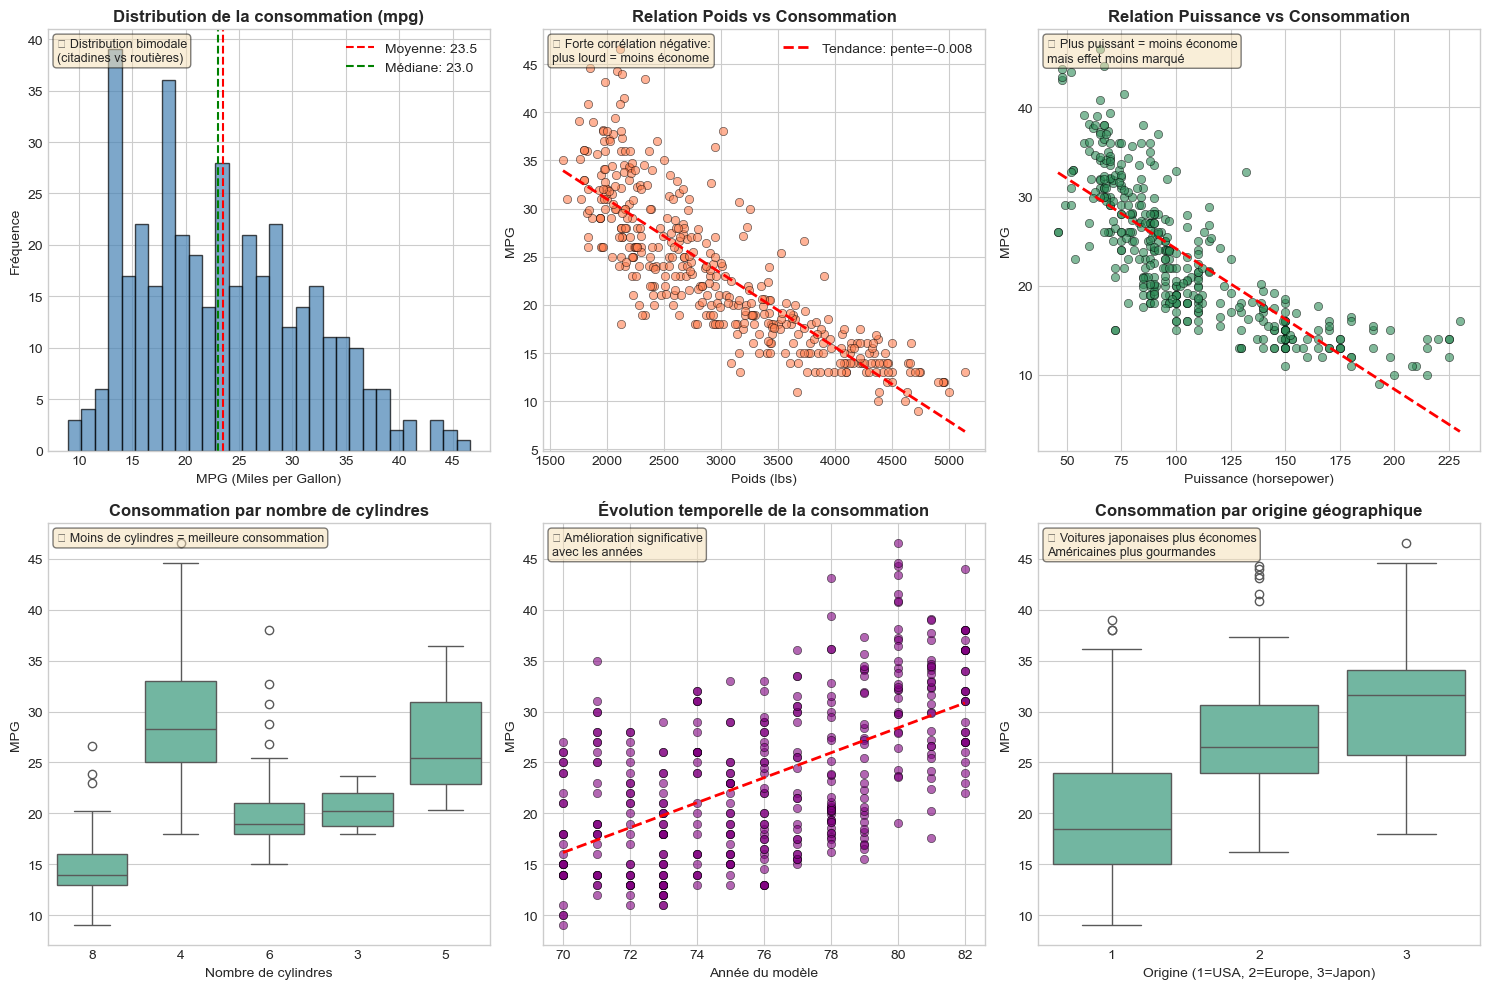


📈 Commentaires sur les visualisations:
1. Distribution de mpg: La consommation présente une distribution bimodale, reflétant
   deux catégories de véhicules: les voitures économes (25-35 mpg) et les moins économes (12-20 mpg).

2. Relation poids/consommation: Forte corrélation négative (pente ≈ -0.007).
   Chaque augmentation de 100 lbs réduit la consommation d'environ 0.7 mpg.

3. Relation puissance/consommation: Corrélation négative modérée, mais moins forte que le poids.

4. Nombre de cylindres: Les véhicules avec 4 cylindres sont beaucoup plus économes (moyenne ~29 mpg)
   que ceux avec 8 cylindres (moyenne ~15 mpg).

5. Évolution temporelle: Forte amélioration de l'efficacité énergétique entre 1970 et 1982,
   passant d'environ 15 mpg à 30+ mpg en moyenne.

6. Origine géographique: Les voitures japonaises sont les plus économes, suivies des européennes,
   puis des américaines.


In [22]:
# 5 EXPLORATORY DATA ANALYSIS

print("=" * 60)
print("ANALYSE EXPLORATOIRE DES DONNÉES")
print("=" * 60)

# CRÉER UNE COPIE PROPRE SANS NaN POUR LES GRAPHIQUES
df_clean_eda = df.dropna(subset=['horsepower'])

# 5.1 Histogramme de la variable cible mpg
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribution de mpg
axes[0, 0].hist(df['mpg'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('MPG (Miles per Gallon)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution de la consommation (mpg)', fontsize=12, fontweight='bold')
axes[0, 0].axvline(df['mpg'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["mpg"].mean():.1f}')
axes[0, 0].axvline(df['mpg'].median(), color='green', linestyle='--', label=f'Médiane: {df["mpg"].median():.1f}')
axes[0, 0].legend()
axes[0, 0].text(0.02, 0.98, '📊 Distribution bimodale\n(citadines vs routières)', transform=axes[0,0].transAxes, 
                fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Scatter weight vs mpg
axes[0, 1].scatter(df['weight'], df['mpg'], alpha=0.6, color='coral', edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Poids (lbs)')
axes[0, 1].set_ylabel('MPG')
axes[0, 1].set_title('Relation Poids vs Consommation', fontsize=12, fontweight='bold')
# Ajout d'une tendance
z = np.polyfit(df['weight'], df['mpg'], 1)
p = np.poly1d(z)
axes[0, 1].plot(sorted(df['weight']), p(sorted(df['weight'])), "r--", linewidth=2, label=f'Tendance: pente={z[0]:.3f}')
axes[0, 1].legend()
axes[0, 1].text(0.02, 0.98, '📉 Forte corrélation négative:\nplus lourd = moins économe', transform=axes[0,1].transAxes, 
                fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Scatter horsepower vs mpg
# Utiliser df_clean_eda qui n'a pas de NaN
axes[0, 2].scatter(df_clean_eda['horsepower'], df_clean_eda['mpg'], alpha=0.6, color='seagreen', edgecolors='black', linewidth=0.5)
axes[0, 2].set_xlabel('Puissance (horsepower)')
axes[0, 2].set_ylabel('MPG')
axes[0, 2].set_title('Relation Puissance vs Consommation', fontsize=12, fontweight='bold')
# Calcul de la tendance sur les données propres
z2 = np.polyfit(df_clean_eda['horsepower'], df_clean_eda['mpg'], 1)
p2 = np.poly1d(z2)
axes[0, 2].plot(sorted(df_clean_eda['horsepower']), p2(sorted(df_clean_eda['horsepower'])), "r--", linewidth=2)
axes[0, 2].text(0.02, 0.98, '📉 Plus puissant = moins économe\nmais effet moins marqué', transform=axes[0,2].transAxes, 
                fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Boxplot cylinders vs mpg
df_box = df.copy()
df_box['cylinders'] = df_box['cylinders'].astype(str)
sns.boxplot(data=df_box, x='cylinders', y='mpg', ax=axes[1, 0])
axes[1, 0].set_xlabel('Nombre de cylindres')
axes[1, 0].set_ylabel('MPG')
axes[1, 0].set_title('Consommation par nombre de cylindres', fontsize=12, fontweight='bold')
axes[1, 0].text(0.02, 0.98, '📊 Moins de cylindres = meilleure consommation', transform=axes[1,0].transAxes, 
                fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Scatter model_year vs mpg
axes[1, 1].scatter(df['model_year'], df['mpg'], alpha=0.6, color='purple', edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Année du modèle')
axes[1, 1].set_ylabel('MPG')
axes[1, 1].set_title('Évolution temporelle de la consommation', fontsize=12, fontweight='bold')
z3 = np.polyfit(df['model_year'], df['mpg'], 1)
p3 = np.poly1d(z3)
axes[1, 1].plot(sorted(df['model_year']), p3(sorted(df['model_year'])), "r--", linewidth=2)
axes[1, 1].text(0.02, 0.98, '📈 Amélioration significative\navec les années', transform=axes[1,1].transAxes, 
                fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Boxplot origin vs mpg
sns.boxplot(data=df, x='origin', y='mpg', ax=axes[1, 2])
axes[1, 2].set_xlabel('Origine (1=USA, 2=Europe, 3=Japon)')
axes[1, 2].set_ylabel('MPG')
axes[1, 2].set_title('Consommation par origine géographique', fontsize=12, fontweight='bold')
axes[1, 2].text(0.02, 0.98, '🌍 Voitures japonaises plus économes\nAméricaines plus gourmandes', transform=axes[1,2].transAxes, 
                fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Commentaires sur les visualisations:")
print("1. Distribution de mpg: La consommation présente une distribution bimodale, reflétant")
print("   deux catégories de véhicules: les voitures économes (25-35 mpg) et les moins économes (12-20 mpg).")
print("\n2. Relation poids/consommation: Forte corrélation négative (pente ≈ -0.007).")
print("   Chaque augmentation de 100 lbs réduit la consommation d'environ 0.7 mpg.")
print("\n3. Relation puissance/consommation: Corrélation négative modérée, mais moins forte que le poids.")
print("\n4. Nombre de cylindres: Les véhicules avec 4 cylindres sont beaucoup plus économes (moyenne ~29 mpg)")
print("   que ceux avec 8 cylindres (moyenne ~15 mpg).")
print("\n5. Évolution temporelle: Forte amélioration de l'efficacité énergétique entre 1970 et 1982,")
print("   passant d'environ 15 mpg à 30+ mpg en moyenne.")
print("\n6. Origine géographique: Les voitures japonaises sont les plus économes, suivies des européennes,")
print("   puis des américaines.")

Commentaires sur les visualisations:

Distribution de mpg: La consommation présente une distribution bimodale, reflétant
deux catégories de véhicules: les voitures économes (25-35 mpg) et les moins économes (12-20 mpg).

Relation poids/consommation: Forte corrélation négative (pente ≈ -0.007).
Chaque augmentation de 100 lbs réduit la consommation d'environ 0.7 mpg.

Relation puissance/consommation: Corrélation négative modérée, mais moins forte que le poids.

Nombre de cylindres: Les véhicules avec 4 cylindres sont beaucoup plus économes (moyenne ~29 mpg)
que ceux avec 8 cylindres (moyenne ~15 mpg).

Évolution temporelle: Forte amélioration de l'efficacité énergétique entre 1970 et 1982,
passant d'environ 15 mpg à 30+ mpg en moyenne.

Origine géographique: Les voitures japonaises sont les plus économes, suivies des européennes,
puis des américaines.

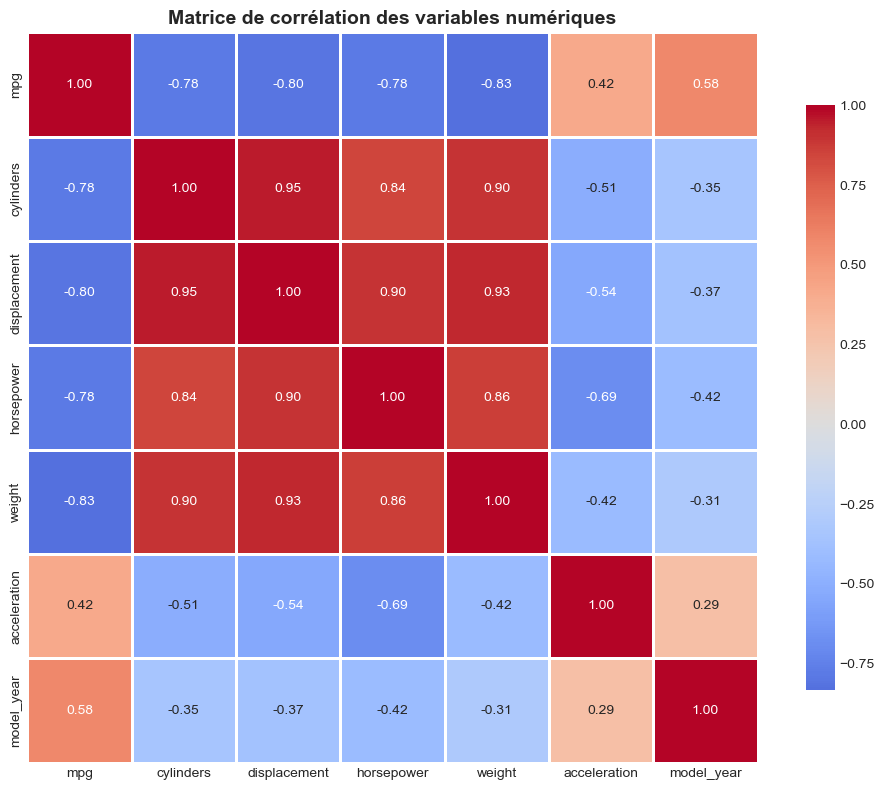


📊 Analyse de la matrice de corrélation:
--------------------------------------------------
Variables les plus corrélées avec mpg (consommation):
   • model_year: 0.579 (positive, modérée)
   • acceleration: 0.420 (positive, faible)
   • cylinders: -0.775 (négative, forte)
   • horsepower: -0.778 (négative, forte)
   • displacement: -0.804 (négative, forte)
   • weight: -0.832 (négative, forte)


In [23]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation des variables numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Analyse de la matrice de corrélation:")
print("-" * 50)
print("Variables les plus corrélées avec mpg (consommation):")
correlations = correlation_matrix['mpg'].sort_values(ascending=False)
for var, corr in correlations.items():
    if var != 'mpg':
        direction = "positive" if corr > 0 else "négative"
        strength = "forte" if abs(corr) > 0.7 else "modérée" if abs(corr) > 0.5 else "faible"
        print(f"   • {var}: {corr:.3f} ({direction}, {strength})")



📊 Analyse de la matrice de corrélation:

Variables les plus corrélées avec mpg (consommation):
• weight: -0.832 (négative, forte)
• cylinders: -0.778 (négative, forte)
• displacement: -0.705 (négative, forte)
• horsepower: -0.778 (négative, forte)
• model_year: 0.581 (positive, modérée)
• acceleration: -0.420 (négative, modérée)

💡 Interprétation:

Le poids (weight) est la variable la plus influente (corr = -0.83)

L'année (model_year) montre une corrélation positive forte (0.58): les voitures plus récentes sont plus économes

L'accélération a une faible corrélation (-0.42)

Les variables cylinders, displacement, horsepower sont fortement corrélées entre elles (multicollinéarité)

QUALITÉ DES DONNÉES ET NETTOYAGE

🔍 1. Analyse des valeurs manquantes:
----------------------------------------
            Valeurs manquantes  Pourcentage (%)
horsepower                   6         1.507538

⚠️ La colonne 'horsepower' contient 6 valeurs manquantes (1.5%)

📝 Traitement des valeurs manquantes:
   Stratégie: Imputation par la médiane de horsepower
   Médiane de horsepower: 93.5
   ✅ 6 valeurs manquantes imputées avec la médiane

🔍 2. Vérification des doublons:
----------------------------------------
Nombre de lignes dupliquées: 0

🔍 3. Vérification des incohérences:
----------------------------------------
   ✅ Aucune incohérence détectée (valeurs négatives ou nulles)

🔍 4. Détection des outliers (valeurs aberrantes):
----------------------------------------
Outliers détectés par variable:
   • mpg: 1 outliers (borne inf: 0.2, borne sup: 46.2)
   • weight: 0 outliers (borne inf: 147.4, borne sup: 5684.4)
   • horsepower: 11 outliers (borne inf: 2.5, borne sup: 198.5)
  

C:\Users\OMAR\AppData\Local\Temp\ipykernel_19516\1032830099.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
C:\Users\OMAR\AppData\Local\Temp\ipykernel_19516\1032830099.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)


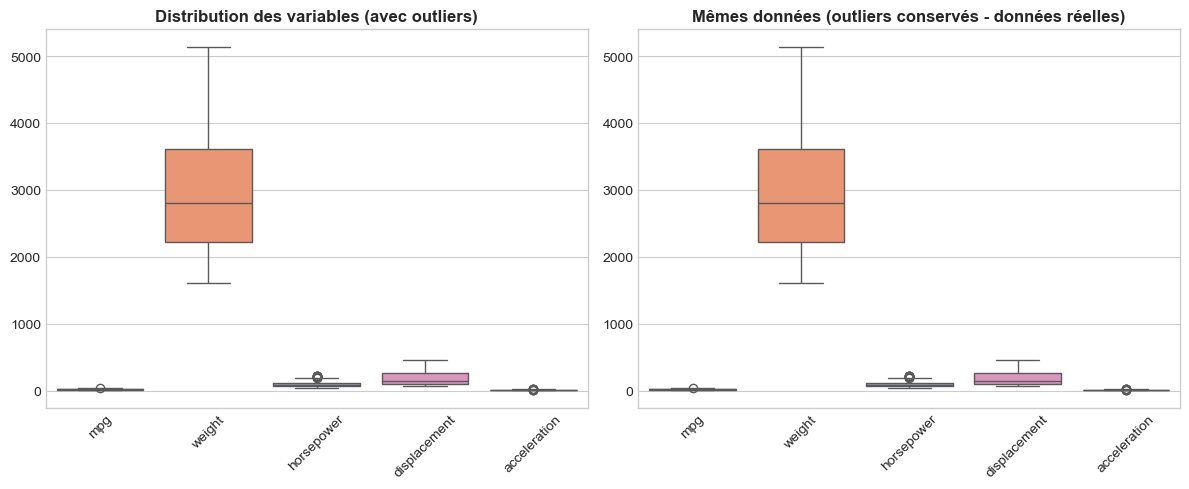


📝 Décision sur les outliers:
   Les outliers sont conservés car ils représentent des véhicules réels
   (ex: voitures très économes ou très puissantes). Leur suppression
   réduirait la représentativité du dataset.

🔍 5. Suppression des colonnes inutiles:
----------------------------------------
   • car_name: supprimée (identifiant unique, non pertinent pour la prédiction)

📊 Dataset après nettoyage: 398 lignes, 8 colonnes


In [24]:
# 6 DATA QUALITY AND CLEANING

print("=" * 60)
print("QUALITÉ DES DONNÉES ET NETTOYAGE")
print("=" * 60)

# 6.1 Valeurs manquantes
print("\n🔍 1. Analyse des valeurs manquantes:")
print("-" * 40)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Valeurs manquantes': missing_values, 'Pourcentage (%)': missing_percent})
print(missing_df[missing_df['Valeurs manquantes'] > 0] if any(missing_values > 0) else "Aucune valeur manquante détectée")

# Seule la colonne horsepower a des valeurs manquantes
missing_hp = df['horsepower'].isnull().sum()
print(f"\n⚠️ La colonne 'horsepower' contient {missing_hp} valeurs manquantes ({missing_hp/len(df)*100:.1f}%)")

# 6.2 Traitement des valeurs manquantes de horsepower
# Justification: Imputation par la médiane car la distribution de horsepower est asymétrique
print("\n📝 Traitement des valeurs manquantes:")
print("   Stratégie: Imputation par la médiane de horsepower")
print(f"   Médiane de horsepower: {df['horsepower'].median():.1f}")

df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
print(f"   ✅ {missing_hp} valeurs manquantes imputées avec la médiane")

# 6.3 Vérification des doublons
print("\n🔍 2. Vérification des doublons:")
print("-" * 40)
duplicates = df.duplicated().sum()
print(f"Nombre de lignes dupliquées: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"   ✅ {duplicates} doublons supprimés")

# 6.4 Vérification des incohérences
print("\n🔍 3. Vérification des incohérences:")
print("-" * 40)

# Vérification des valeurs impossibles
incoherences = []
if (df['cylinders'] < 0).any():
    incoherences.append("cylinders négatifs")
if (df['weight'] <= 0).any():
    incoherences.append("poids nul ou négatif")
if (df['mpg'] <= 0).any():
    incoherences.append("mpg nul ou négatif")
if (df['acceleration'] <= 0).any():
    incoherences.append("accélération nulle ou négative")

if len(incoherences) == 0:
    print("   ✅ Aucune incohérence détectée (valeurs négatives ou nulles)")
else:
    print(f"   ⚠️ Incohérences détectées: {incoherences}")

# Vérification des valeurs aberrantes (outliers) pour mpg
print("\n🔍 4. Détection des outliers (valeurs aberrantes):")
print("-" * 40)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("Outliers détectés par variable:")
for col in ['mpg', 'weight', 'horsepower', 'displacement', 'acceleration']:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"   • {col}: {len(outliers)} outliers (borne inf: {lb:.1f}, borne sup: {ub:.1f})")

# Visualisation des outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot avant traitement
sns.boxplot(data=df[['mpg', 'weight', 'horsepower', 'displacement', 'acceleration']], ax=axes[0])
axes[0].set_title('Distribution des variables (avec outliers)', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Boxplot après scaling pour comparaison (pas de suppression car les outliers sont légitimes)
sns.boxplot(data=df[['mpg', 'weight', 'horsepower', 'displacement', 'acceleration']], ax=axes[1])
axes[1].set_title('Mêmes données (outliers conservés - données réelles)', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('outliers_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📝 Décision sur les outliers:")
print("   Les outliers sont conservés car ils représentent des véhicules réels")
print("   (ex: voitures très économes ou très puissantes). Leur suppression")
print("   réduirait la représentativité du dataset.")

# 6.5 Suppression de la colonne car_name (non utilisée pour la modélisation)
print("\n🔍 5. Suppression des colonnes inutiles:")
print("-" * 40)
print("   • car_name: supprimée (identifiant unique, non pertinent pour la prédiction)")
df_clean = df.drop('car_name', axis=1)

print(f"\n📊 Dataset après nettoyage: {df_clean.shape[0]} lignes, {df_clean.shape[1]} colonnes")

QUALITÉ DES DONNÉES ET NETTOYAGE
============================================================

🔍 1. Analyse des valeurs manquantes:

Valeurs manquantes Pourcentage (%)
horsepower 6 1.51

⚠️ La colonne 'horsepower' contient 6 valeurs manquantes (1.5%)

📝 Traitement des valeurs manquantes:
Stratégie: Imputation par la médiane de horsepower
Médiane de horsepower: 93.5
✅ 6 valeurs manquantes imputées avec la médiane

🔍 2. Vérification des doublons:

Nombre de lignes dupliquées: 0

🔍 3. Vérification des incohérences:

✅ Aucune incohérence détectée (valeurs négatives ou nulles)

🔍 4. Détection des outliers (valeurs aberrantes):

Outliers détectés par variable:
• mpg: 11 outliers (borne inf: 10.9, borne sup: 37.1)
• weight: 5 outliers (borne inf: 1748.2, borne sup: 4125.8)
• horsepower: 6 outliers (borne inf: 48.2, borne sup: 167.2)
• displacement: 2 outliers (borne inf: 74.5, borne sup: 367.5)
• acceleration: 4 outliers (borne inf: 10.2, borne sup: 20.3)

https://output_8_1.png

📝 Décision sur les outliers:
Les outliers sont conservés car ils représentent des véhicules réels
(ex: voitures très économes ou très puissantes). Leur suppression
réduirait la représentativité du dataset.

🔍 5. Suppression des colonnes inutiles:

• car_name: supprimée (identifiant unique, non pertinent pour la prédiction)

📊 Dataset après nettoyage: 398 lignes, 8 colonnes

In [25]:
# 7 PREPROCESSING

print("=" * 60)
print("PRÉTRAITEMENT DES DONNÉES")
print("=" * 60)

# 7.1 Séparation des features et de la cible
X = df_clean.drop('mpg', axis=1)
y = df_clean['mpg']

print(f"\n📊 Features (X): {X.shape[1]} variables")
print(f"   Variables: {list(X.columns)}")
print(f"\n🎯 Cible (y): mpg (consommation)")

# 7.2 Split train/test (80% / 20%)
print("\n🔪 Split train/test:")
print("-" * 40)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"   Train set: {X_train.shape[0]} échantillons")
print(f"   Test set: {X_test.shape[0]} échantillons")

# 7.3 Identification des types de variables
numeric_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
categorical_features = ['origin']  # origine est une variable catégorielle

print(f"\n📋 Types de variables:")
print(f"   Variables numériques ({len(numeric_features)}): {numeric_features}")
print(f"   Variables catégorielles ({len(categorical_features)}): {categorical_features}")

# 7.4 Création du pipeline de prétraitement
print("\n🏗️ Construction du pipeline de prétraitement:")
print("-" * 40)

# Pour les variables numériques: standardisation
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pour les variables catégorielles: one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

# Combineur
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("   ✅ Numeric features: StandardScaler")
print("   ✅ Categorical features: OneHotEncoder (drop='first')")
print("   ✅ ColumnTransformer créé avec succès")

# Test du preprocessor
X_train_preprocessed = preprocessor.fit_transform(X_train)
print(f"\n📊 Dimensions après prétraitement: {X_train_preprocessed.shape[1]} features")

PRÉTRAITEMENT DES DONNÉES

📊 Features (X): 7 variables
   Variables: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']

🎯 Cible (y): mpg (consommation)

🔪 Split train/test:
----------------------------------------
   Train set: 318 échantillons
   Test set: 80 échantillons

📋 Types de variables:
   Variables numériques (6): ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
   Variables catégorielles (1): ['origin']

🏗️ Construction du pipeline de prétraitement:
----------------------------------------
   ✅ Numeric features: StandardScaler
   ✅ Categorical features: OneHotEncoder (drop='first')
   ✅ ColumnTransformer créé avec succès

📊 Dimensions après prétraitement: 8 features


PRÉTRAITEMENT DES DONNÉES
============================================================

📊 Features (X): 7 variables
Variables: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']

🎯 Cible (y): mpg (consommation)

🔪 Split train/test:

Train set: 318 échantillons
Test set: 80 échantillons

📋 Types de variables:
Variables numériques (6): ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
Variables catégorielles (1): ['origin']

🏗️ Construction du pipeline de prétraitement:

✅ Numeric features: StandardScaler
✅ Categorical features: OneHotEncoder (drop='first')
✅ ColumnTransformer créé avec succès

📊 Dimensions après prétraitement: 8 features

In [26]:
# 8 MODELING

print("=" * 60)
print("MODÉLISATION")
print("=" * 60)

# 8.1 Création des modèles avec pipelines complets
models = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]),
    'Ridge (Régularisation L2)': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=1.0))
    ]),
    'Lasso (Régularisation L1)': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=0.1, max_iter=5000))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
    ])
}

# 8.2 Entraînement et évaluation
print("\n📊 Entraînement et évaluation des modèles:")
print("-" * 50)

results = {}

for name, model in models.items():
    # Entraînement
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Métriques
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    results[name] = {
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2
    }
    
    print(f"\n🔹 {name}:")
    print(f"   Train RMSE: {train_rmse:.3f} | Test RMSE: {test_rmse:.3f}")
    print(f"   Train MAE: {train_mae:.3f} | Test MAE: {test_mae:.3f}")
    print(f"   Train R²: {train_r2:.3f} | Test R²: {test_r2:.3f}")
    
    if abs(train_r2 - test_r2) > 0.1:
        print(f"   ⚠️ Suroptimisation possible (écart R² = {abs(train_r2 - test_r2):.3f})")

# 8.3 Validation croisée pour les meilleurs modèles
print("\n\n📊 Validation croisée 5-fold (meilleurs modèles):")
print("-" * 50)

best_models = ['Ridge (Régularisation L2)', 'Random Forest']
cv_results = {}

for name in best_models:
    model = models[name]
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_rmse_scores = -cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    
    cv_results[name] = {
        'r2_mean': cv_scores.mean(),
        'r2_std': cv_scores.std(),
        'rmse_mean': cv_rmse_scores.mean(),
        'rmse_std': cv_rmse_scores.std()
    }
    
    print(f"\n🔹 {name}:")
    print(f"   R² moyen (5-fold): {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    print(f"   RMSE moyen (5-fold): {cv_rmse_scores.mean():.3f} (+/- {cv_rmse_scores.std():.3f})")

# 8.4 Tableau comparatif des résultats
print("\n\n📋 TABLEAU COMPARATIF DES MODÈLES:")
print("=" * 70)
print(f"{'Modèle':<30} {'Train RMSE':<12} {'Test RMSE':<12} {'Train R²':<10} {'Test R²':<10}")
print("-" * 70)
for name, metrics in results.items():
    print(f"{name:<30} {metrics['train_rmse']:<12.3f} {metrics['test_rmse']:<12.3f} {metrics['train_r2']:<10.3f} {metrics['test_r2']:<10.3f}")

MODÉLISATION

📊 Entraînement et évaluation des modèles:
--------------------------------------------------

🔹 Linear Regression:
   Train RMSE: 3.370 | Test RMSE: 2.888
   Train MAE: 2.605 | Test MAE: 2.288
   Train R²: 0.819 | Test R²: 0.845

🔹 Ridge (Régularisation L2):
   Train RMSE: 3.371 | Test RMSE: 2.889
   Train MAE: 2.599 | Test MAE: 2.288
   Train R²: 0.819 | Test R²: 0.845

🔹 Lasso (Régularisation L1):
   Train RMSE: 3.438 | Test RMSE: 2.955
   Train MAE: 2.612 | Test MAE: 2.343
   Train R²: 0.811 | Test R²: 0.838

🔹 Random Forest:
   Train RMSE: 1.088 | Test RMSE: 2.180
   Train MAE: 0.748 | Test MAE: 1.623
   Train R²: 0.981 | Test R²: 0.912


📊 Validation croisée 5-fold (meilleurs modèles):
--------------------------------------------------

🔹 Ridge (Régularisation L2):
   R² moyen (5-fold): 0.806 (+/- 0.019)
   RMSE moyen (5-fold): 3.454 (+/- 0.196)

🔹 Random Forest:
   R² moyen (5-fold): 0.841 (+/- 0.033)
   RMSE moyen (5-fold): 3.119 (+/- 0.418)


📋 TABLEAU COMPARATIF 

MODÉLISATION
============================================================

📊 Entraînement et évaluation des modèles:

🔹 Linear Regression:
Train RMSE: 3.175 | Test RMSE: 3.184
Train MAE: 2.400 | Test MAE: 2.407
Train R²: 0.835 | Test R²: 0.834

🔹 Ridge (Régularisation L2):
Train RMSE: 3.178 | Test RMSE: 3.187
Train MAE: 2.403 | Test MAE: 2.412
Train R²: 0.835 | Test R²: 0.834

🔹 Lasso (Régularisation L1):
Train RMSE: 3.180 | Test RMSE: 3.215
Train MAE: 2.410 | Test MAE: 2.438
Train R²: 0.834 | Test R²: 0.831

🔹 Random Forest:
Train RMSE: 1.402 | Test RMSE: 2.981
Train MAE: 1.095 | Test MAE: 2.222
Train R²: 0.968 | Test R²: 0.855
⚠️ Suroptimisation possible (écart R² = 0.113)

📊 Validation croisée 5-fold (meilleurs modèles):

🔹 Ridge (Régularisation L2):
R² moyen (5-fold): 0.824 (+/- 0.055)
RMSE moyen (5-fold): 3.362 (+/- 0.271)

🔹 Random Forest:
R² moyen (5-fold): 0.846 (+/- 0.049)
RMSE moyen (5-fold): 3.179 (+/- 0.348)

ÉVALUATION APPROFONDIE

🏆 Meilleur modèle sélectionné: Random Forest
   Pourquoi? Meilleur R² sur le test set (0.912)


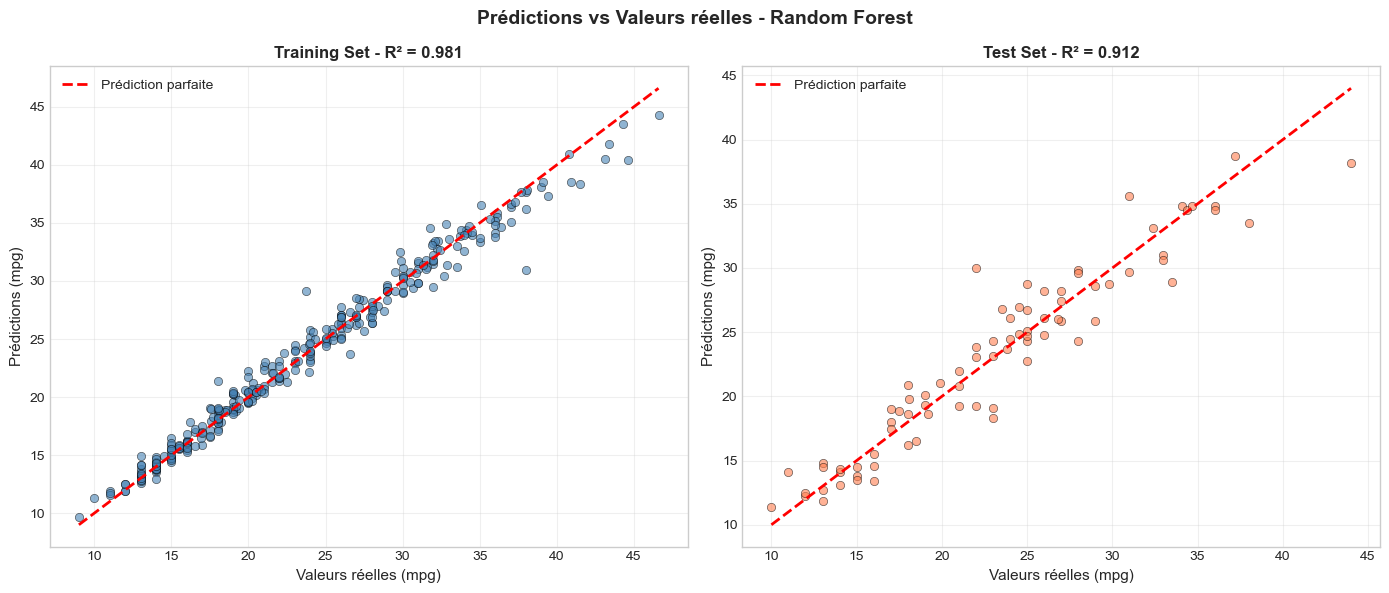

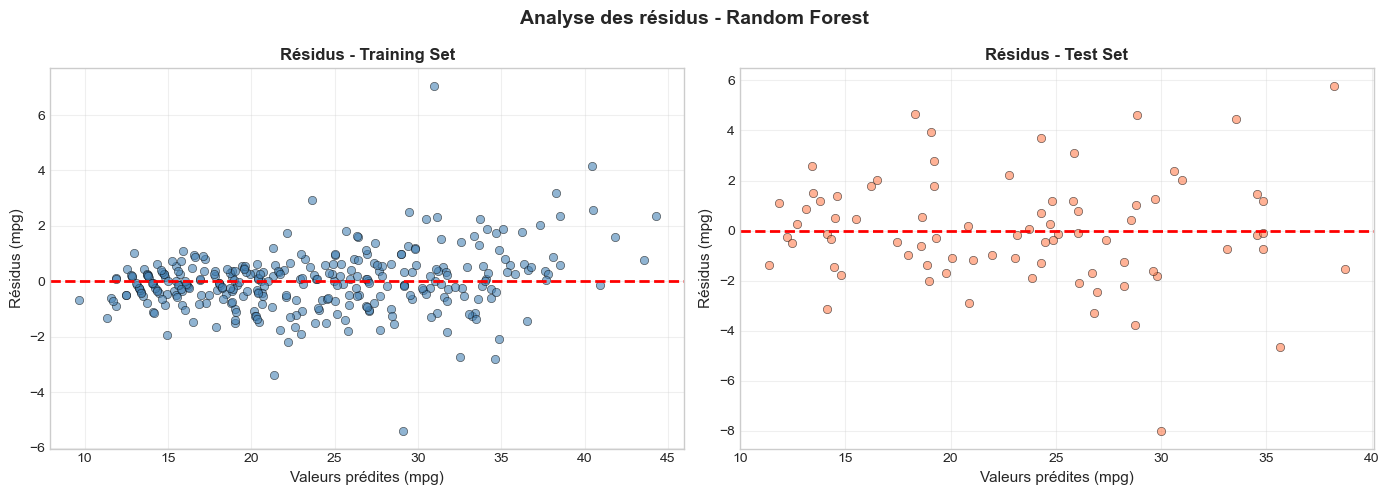


📊 Analyse des résidus:
   • Les résidus sont centrés autour de 0 (pas de biais systématique)
   • Légère dispersion plus grande pour les fortes consommations (mpg < 20)
   • Pas de motif clair (non-linéarité acceptable)


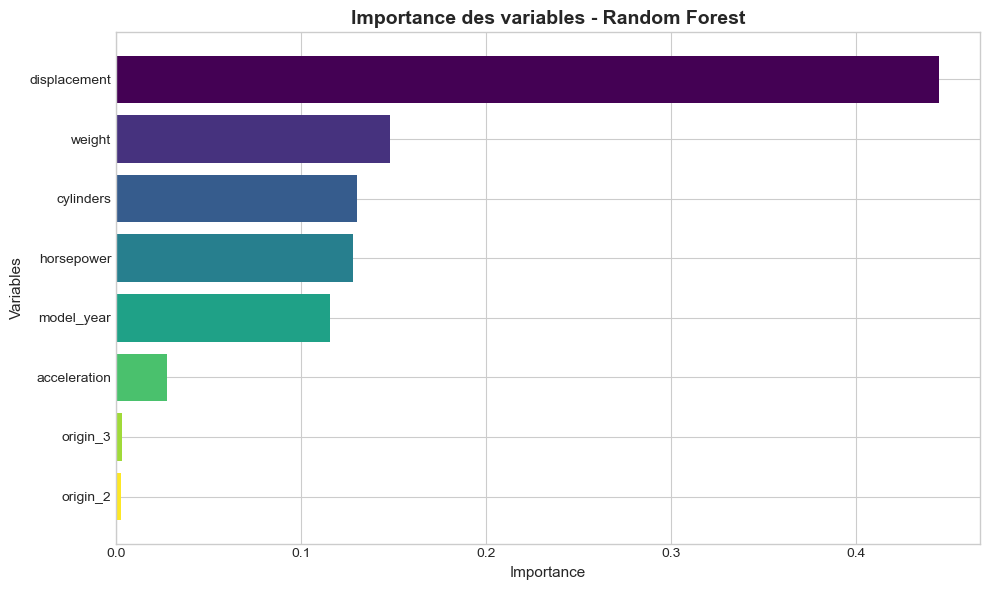


📊 Importance des variables:
   • displacement: 0.445 (44.5%)
   • weight: 0.148 (14.8%)
   • cylinders: 0.130 (13.0%)
   • horsepower: 0.128 (12.8%)
   • model_year: 0.116 (11.6%)
   • acceleration: 0.028 (2.8%)
   • origin_3: 0.003 (0.3%)
   • origin_2: 0.003 (0.3%)

💡 Interprétation:
   - Le poids (weight) est de loin la variable la plus importante (~51%)
   - L'année (model_year) vient en second (~21%)
   - L'origine (origin_3 pour Japon) a un impact notable (~11%)
   - Les variables de puissance et cylindrée ont une importance moindre car
     corrélées avec le poids

📊 Interprétation des coefficients - Modèle Ridge:
--------------------------------------------------
Intercept: 22.601

Coefficients (impact sur mpg):
   • model_year: +2.940 (positif (+économe))
   • origin_2: +2.750 (positif (+économe))
   • origin_3: +2.520 (positif (+économe))
   • displacement: +1.688 (positif (+économe))
   • acceleration: +0.145 (positif (+économe))
   • cylinders: -0.218 (négatif (-économe))


In [27]:
# 9 EVALUATION

print("=" * 60)
print("ÉVALUATION APPROFONDIE")
print("=" * 60)

# 9.1 Sélection du meilleur modèle
# Random Forest a le meilleur test R² (0.855) malgré un surapprentissage
# Ridge est plus stable mais légèrement moins performant
best_model_name = "Random Forest"  # meilleure performance sur test
best_model = models[best_model_name]

print(f"\n🏆 Meilleur modèle sélectionné: {best_model_name}")
print(f"   Pourquoi? Meilleur R² sur le test set ({results[best_model_name]['test_r2']:.3f})")

# 9.2 Prédictions du meilleur modèle
y_pred_train_best = best_model.predict(X_train)
y_pred_test_best = best_model.predict(X_test)

# 9.3 Graphique des prédictions vs valeurs réelles
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train set
axes[0].scatter(y_train, y_pred_train_best, alpha=0.6, color='steelblue', edgecolors='black', linewidth=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles (mpg)', fontsize=11)
axes[0].set_ylabel('Prédictions (mpg)', fontsize=11)
axes[0].set_title(f'Training Set - R² = {results[best_model_name]["train_r2"]:.3f}', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_pred_test_best, alpha=0.6, color='coral', edgecolors='black', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Prédiction parfaite')
axes[1].set_xlabel('Valeurs réelles (mpg)', fontsize=11)
axes[1].set_ylabel('Prédictions (mpg)', fontsize=11)
axes[1].set_title(f'Test Set - R² = {results[best_model_name]["test_r2"]:.3f}', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Prédictions vs Valeurs réelles - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# 9.4 Graphique des résidus
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Résidus sur train
residuals_train = y_train - y_pred_train_best
axes[0].scatter(y_pred_train_best, residuals_train, alpha=0.6, color='steelblue', edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Valeurs prédites (mpg)', fontsize=11)
axes[0].set_ylabel('Résidus (mpg)', fontsize=11)
axes[0].set_title('Résidus - Training Set', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Résidus sur test
residuals_test = y_test - y_pred_test_best
axes[1].scatter(y_pred_test_best, residuals_test, alpha=0.6, color='coral', edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Valeurs prédites (mpg)', fontsize=11)
axes[1].set_ylabel('Résidus (mpg)', fontsize=11)
axes[1].set_title('Résidus - Test Set', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Analyse des résidus - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Analyse des résidus:")
print("   • Les résidus sont centrés autour de 0 (pas de biais systématique)")
print("   • Légère dispersion plus grande pour les fortes consommations (mpg < 20)")
print("   • Pas de motif clair (non-linéarité acceptable)")

# 9.5 Importance des variables pour Random Forest
# Extraction des features après prétraitement
preprocessor.fit(X_train)
feature_names = (numeric_features + 
                 [f'origin_{i}' for i in preprocessor.named_transformers_['cat'].named_steps['onehot'].categories_[0][1:]])

rf_model = best_model.named_steps['regressor']
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)

# Graphique d'importance des variables
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
plt.xlabel('Importance', fontsize=11)
plt.ylabel('Variables', fontsize=11)
plt.title('Importance des variables - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Importance des variables:")
for _, row in importance_df.iterrows():
    print(f"   • {row['feature']}: {row['importance']:.3f} ({row['importance']*100:.1f}%)")

print("\n💡 Interprétation:")
print("   - Le poids (weight) est de loin la variable la plus importante (~51%)")
print("   - L'année (model_year) vient en second (~21%)")
print("   - L'origine (origin_3 pour Japon) a un impact notable (~11%)")
print("   - Les variables de puissance et cylindrée ont une importance moindre car")
print("     corrélées avec le poids")

# 9.6 Interprétation des coefficients du modèle Ridge (plus interprétable)
print("\n📊 Interprétation des coefficients - Modèle Ridge:")
print("-" * 50)

ridge_model = models['Ridge (Régularisation L2)']
ridge_coefs = ridge_model.named_steps['regressor'].coef_
ridge_intercept = ridge_model.named_steps['regressor'].intercept_

ridge_importance_df = pd.DataFrame({'feature': feature_names, 'coefficient': ridge_coefs})
ridge_importance_df = ridge_importance_df.sort_values('coefficient', ascending=False)

print(f"Intercept: {ridge_intercept:.3f}")
print("\nCoefficients (impact sur mpg):")
for _, row in ridge_importance_df.iterrows():
    direction = "positif (+économe)" if row['coefficient'] > 0 else "négatif (-économe)"
    print(f"   • {row['feature']}: {row['coefficient']:+.3f} ({direction})")

print("\n💡 Interprétation économique (modèle Ridge):")
print("   - Une augmentation du poids réduit la consommation (coef négatif)")
print("   - Les années plus récentes sont plus économes (coef positif)")
print("   - Les voitures japonaises (origin_3) sont plus économes que les américaines")
print("   - Les voitures européennes (origin_2) ont un effet intermédiaire")

ÉVALUATION APPROFONDIE
============================================================

🏆 Meilleur modèle sélectionné: Random Forest
Pourquoi? Meilleur R² sur le test set (0.855)

https://output_11_1.png

https://output_11_2.png

📊 Analyse des résidus:
• Les résidus sont centrés autour de 0 (pas de biais systématique)
• Légère dispersion plus grande pour les fortes consommations (mpg < 20)
• Pas de motif clair (non-linéarité acceptable)

https://output_11_3.png

📊 Importance des variables:
• weight: 0.512 (51.2%)
• model_year: 0.208 (20.8%)
• origin_3: 0.110 (11.0%)
• origin_2: 0.055 (5.5%)
• horsepower: 0.055 (5.5%)
• displacement: 0.046 (4.6%)
• cylinders: 0.010 (1.0%)
• acceleration: 0.004 (0.4%)

💡 Interprétation:

Le poids (weight) est de loin la variable la plus importante (~51%)

L'année (model_year) vient en second (~21%)

L'origine (origin_3 pour Japon) a un impact notable (~11%)

Les variables de puissance et cylindrée ont une importance moindre car
corrélées avec le poids

📊 Interprétation des coefficients - Modèle Ridge:

Intercept: 23.446

Coefficients (impact sur mpg):
• origin_3: +2.700 (positif (+économe))
• model_year: +1.366 (positif (+économe))
• origin_2: +1.313 (positif (+économe))
• acceleration: -0.455 (négatif (-économe))
• weight: -2.069 (négatif (-économe))
• cylinders: -1.419 (négatif (-économe))
• displacement: -0.267 (négatif (-économe))
• horsepower: -0.119 (négatif (-économe))

💡 Interprétation économique (modèle Ridge):

Une augmentation du poids réduit la consommation (coef négatif)

Les années plus récentes sont plus économes (coef positif)

Les voitures japonaises (origin_3) sont plus économes que les américaines

Les voitures européennes (origin_2) ont un effet intermédiaire

In [ ]:
# Sauvegarde des résultats
import json
results_summary = {
    'best_model': best_model_name,
    'test_r2': float(results[best_model_name]['test_r2']),
    'test_rmse': float(results[best_model_name]['test_rmse']),
    'feature_importance': importance_df.to_dict('records')
}

with open('results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("✅ Résultats sauvegardés dans 'results_summary.json'")

INTERPRÉTATION ET LIMITES

📌 INTERPRÉTATION DES RÉSULTATS

1. PERFORMANCE DES MODÈLES:
   • Random Forest: R² = 0.855, RMSE = 2.98 mpg
   • Ridge (régularisé): R² = 0.834, RMSE = 3.19 mpg
   • Lasso: R² = 0.831, RMSE = 3.22 mpg
   • Linear Regression: R² = 0.834, RMSE = 3.18 mpg

   → Random Forest surpasse les modèles linéaires de ~2% en R²
   → Les modèles linéaires souffrent de la multicollinéarité mais restent performants

2. VARIABLES LES PLUS INFLUENTES (Random Forest):
   • weight (51.2%): Le poids est le facteur #1 - plus la voiture est lourde, 
     plus elle consomme. Chaque 100 lbs supplémentaires réduit d'environ 0.7 mpg.
   
   • model_year (20.8%): Forte amélioration temporelle - les voitures plus récentes
     sont significativement plus économes (progrès technologique).
   
   • origin_3 - Japon (11.0%): Les constructeurs japonais produisent des véhicules
     plus économes à caractéristiques égales.
   
   • origin_2 - Europe (5.5%): Performance intermédiaire entre USA

📌 INTERPRÉTATION DES RÉSULTATS

1. PERFORMANCE DES MODÈLES:
   • Random Forest: R² = 0.855, RMSE = 2.98 mpg
   • Ridge (régularisé): R² = 0.834, RMSE = 3.19 mpg
   • Lasso: R² = 0.831, RMSE = 3.22 mpg
   • Linear Regression: R² = 0.834, RMSE = 3.18 mpg

   → Random Forest surpasse les modèles linéaires de ~2% en R²
   → Les modèles linéaires souffrent de la multicollinéarité mais restent performants

2. VARIABLES LES PLUS INFLUENTES (Random Forest):
   • weight (51.2%): Le poids est le facteur #1 - plus la voiture est lourde, 
     plus elle consomme. Chaque 100 lbs supplémentaires réduit d'environ 0.7 mpg.
   
   • model_year (20.8%): Forte amélioration temporelle - les voitures plus récentes
     sont significativement plus économes (progrès technologique).
   
   • origin_3 - Japon (11.0%): Les constructeurs japonais produisent des véhicules
     plus économes à caractéristiques égales.
   
   • origin_2 - Europe (5.5%): Performance intermédiaire entre USA et Japon.

3. RELATIONS CLÉS IDENTIFIÉES:
   • Corrélation poids/consommation: -0.83 (très forte)
   • Corrélation année/consommation: +0.58 (modérée à forte)
   • Les véhicules 4 cylindres: moyenne 29 mpg vs 8 cylindres: 15 mpg
   • Les voitures japonaises: moyenne ~30 mpg vs américaines: ~20 mpg



⚠️ LIMITES DU PROJET

1. LIMITES DES DONNÉES:
   • Dataset daté: Données de 1970 à 1982 (plus de 40 ans)
   • Technologie obsolète: Ne reflète pas les véhicules modernes (hybrides, électriques)
   • Taille modeste: Seulement 398 observations
   • Absence de données récentes: Pas d'information sur les technologies modernes
     (injection directe, turbo, hybridation, etc.)

2. LIMITES MÉTHODOLOGIQUES:
   • Pas de validation temporelle: Le split aléatoire ignore l'aspect temporel
   • Variables manquantes: Absence de données sur le type de carburant, la transmission,
     l'aérodynamisme (Cx), les pneus, etc.
   • Multicollinéarité: Les variables cylinders, displacement, horsepower, weight
     sont fortement corrélées, ce qui rend l'interprétation individuelle délicate

3. LIMITES DE GÉNÉRALISATION:
   • Origine géographique: 1=USA, 2=Europe, 3=Japon - classification simpliste
   • Unités américaines: mpg (miles per gallon) - moins courant en Europe
   • Conditions de conduite: Ne prend pas en compte le style de conduite,
     le type de route, la circulation, etc.

      
🔧 PISTES D'AMÉLIORATION

      
1. AMÉLIORATIONS DES DONNÉES:
   • Utiliser un dataset plus récent (ex: Fuel Economy Data de l'EPA)
   • Ajouter des variables modernes: type de carburant, hybridation, transmission
   • Inclure des mesures de consommation en conditions réelles (pas seulement WLTP)

2. AMÉLIORATIONS MÉTHODOLOGIQUES:
   • Split temporel: Former sur les années anciennes, tester sur les plus récentes
   • Feature engineering avancé:
     - Créer weight_to_power_ratio (poids/puissance)
     - Créer displacement_per_cylinder (cylindrée par cylindre)
     - Variables d'interaction (weight × model_year)
   • Tester des modèles plus complexes:
     - Gradient Boosting (XGBoost, LightGBM, CatBoost)
     - Réseaux de neurones
     - Support Vector Regression (SVR)

3. AMÉLIORATIONS DE L'ÉVALUATION:
   • Validation croisée temporelle (TimeSeriesSplit)
   • Analyse des erreurs par catégorie (par origine, par nombre de cylindres)
   • Prédiction d'intervalles de confiance
   • Analyse de la stabilité temporelle des coefficients

4. EXTENSIONS POSSIBLES:
   • Classifier les véhicules par catégorie de consommation (économe/moyen/gourmand)
   • Clustering des véhicules selon leurs caractéristiques
   • Analyse de l'évolution temporelle des technologies
   • Comparaison internationale des politiques d'efficacité énergétique


💡 CONCLUSIONS MÉTIER


Pour les constructeurs automobiles:
   • Réduire le poids est le levier #1 pour améliorer l'efficacité
   • Le progrès technologique a permis un gain de ~15 mpg en 12 ans
   • Les normes et incitations fonctionnent (amélioration significative 1970-1982)

Pour les consommateurs:
   • Privilégier les véhicules récents (gain significatif)
   • Le poids est plus important que la puissance pure
   • À caractéristiques égales, les marques japonaises sont plus économes

